# **Librerias** 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Funciones

In [2]:
%matplotlib inline

def EDA(data):
    # Definir variables para el análisis
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    categorical_cols = data.select_dtypes(include=['object']).columns

    print(f'Variables numéricas: {numeric_cols}')
    print(f'Variables categóricas: {categorical_cols}')

    # Crear figura con 3 columnas (Histograma, Boxplot, Violin) y 4 filas (una por cada variable)
    fig, axes = plt.subplots(len(numeric_cols), 3, figsize=(18, 5*len(numeric_cols)))
    fig.suptitle('ANÁLISIS EXPLORATORIO: Histograma, Boxplot y Violin Plot', 
                fontsize=16, fontweight='bold', y=0.995)

    for idx, col in enumerate(numeric_cols):
        # HISTOGRAMA
        axes[idx, 0].hist(data[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx, 0].set_title(f'Histograma: {col}', fontweight='bold')
        axes[idx, 0].set_xlabel('Valor')
        axes[idx, 0].set_ylabel('Frecuencia')
        axes[idx, 0].grid(axis='y', alpha=0.3)
        
        # BOXPLOT
        axes[idx, 1].boxplot(data[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='lightblue', alpha=0.7),
                            medianprops=dict(color='red', linewidth=2))
        axes[idx, 1].set_title(f'Boxplot: {col}', fontweight='bold')
        axes[idx, 1].set_ylabel('Valor')
        axes[idx, 1].grid(axis='y', alpha=0.3)
        
        # VIOLIN PLOT
        parts = axes[idx, 2].violinplot(data[col].dropna(), vert=True, showmeans=True, showmedians=True)
        axes[idx, 2].set_title(f'Violin Plot: {col}', fontweight='bold')
        axes[idx, 2].set_ylabel('Valor')
        axes[idx, 2].grid(axis='y', alpha=0.3)

    plt.tight_layout()

    plt.show()

    

    print('='*80)
    print('ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS')
    print('='*80)
    print()
    print(data[numeric_cols].describe().to_string())

    print('\n' + '='*80)
    print('ANÁLISIS DETALLADO POR VARIABLE')
    print('='*80)

    for col in numeric_cols:
        print(f'\n📊 {col}')
        print(f'   Media: {data[col].mean():.4f}')
        print(f'   Mediana: {data[col].median():.4f}')
        print(f'   Desv. Estándar: {data[col].std():.4f}')
        print(f'   Mínimo: {data[col].min():.4f}')
        print(f'   Máximo: {data[col].max():.4f}')
        print(f'   Q1 (25%): {data[col].quantile(0.25):.4f}')
        print(f'   Q3 (75%): {data[col].quantile(0.75):.4f}')
        print(f'   IQR: {data[col].quantile(0.75) - data[col].quantile(0.25):.4f}')
        print(f'   Asimetría (Skewness): {stats.skew(data[col].dropna()):.4f}')
        print(f'   Curtosis (Kurtosis): {stats.kurtosis(data[col].dropna()):.4f}')

    # Calcular matriz de correlación
    correlation_matrix = data[numeric_cols].corr()

    print('='*80)
    print('MATRIZ DE CORRELACIÓN (PEARSON)')
    print('='*80)
    print(correlation_matrix.to_string())

    # Visualizar matriz de correlación
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=2, cbar_kws={'shrink': 0.8}, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title('MATRIZ DE CORRELACIÓN DE PEARSON\nVariables Numéricas', 
                fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    
    plt.show()

    

    print('='*80)
    print('CORRELACIONES POR PARES - ANÁLISIS DETALLADO')
    print('='*80)

    correlations_list = []
    for i in range(len(numeric_cols)):
        for j in range(i+1, len(numeric_cols)):
            col1, col2 = numeric_cols[i], numeric_cols[j]
            
            # Pearson
            pearson_r, pearson_p = stats.pearsonr(data[col1].dropna(), data[col2].dropna())
            
            # Spearman
            spearman_r, spearman_p = stats.spearmanr(data[col1].dropna(), data[col2].dropna())
            
            correlations_list.append({
                'Variable 1': col1[:35],
                'Variable 2': col2[:35],
                'Pearson r': round(pearson_r, 4),
                'Pearson p-value': round(pearson_p, 6),
                'Spearman r': round(spearman_r, 4),
                'Spearman p-value': round(spearman_p, 6)
            })

    corr_results = pd.DataFrame(correlations_list).sort_values('Pearson p-value')
    print()
    print(corr_results.to_string(index=False))

    # Identificar correlaciones significativas
    print('\n' + '='*80)
    print('CORRELACIONES SIGNIFICATIVAS (p < 0.05)')
    print('='*80)
    significant = corr_results[corr_results['Pearson p-value'] < 0.05]
    if len(significant) > 0:
        print(significant.to_string(index=False))
    else:
        print('No se encontraron correlaciones significativas al nivel p < 0.05')

    # Crear scatter plots para todas las correlaciones
    n_pairs = len(correlations_list)
    n_cols = 2
    n_rows = (n_pairs + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle('SCATTER PLOTS - Correlaciones entre Variables Numéricas', 
                fontweight='bold', fontsize=14)

    for idx, row in enumerate(correlations_list):
        ax = axes[idx // n_cols, idx % n_cols]
        
        col1_name = row['Variable 1']
        col2_name = row['Variable 2']
        
        # Encontrar columnas originales completas
        col1 = [c for c in numeric_cols if col1_name in c][0]
        col2 = [c for c in numeric_cols if col2_name in c][0]
        
        # Scatter plot
        ax.scatter(data[col1], data[col2], alpha=0.6, s=50, color='steelblue', 
                edgecolor='black', linewidth=0.5)
        
        # Línea de tendencia
        z = np.polyfit(data[col1].dropna(), data[col2].dropna(), 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[col1].min(), data[col1].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8, label='Línea de tendencia')
        
        ax.set_xlabel(col1[:30], fontweight='bold')
        ax.set_ylabel(col2[:30], fontweight='bold')
        ax.set_title(f'r = {row["Pearson r"]:.3f} (p={row["Pearson p-value"]:.4f})', 
                    fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend()

    # Ocultar subplots vacíos
    for idx in range(n_pairs, n_rows*n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    plt.tight_layout()
    
    plt.show()

   

    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 5))
    fig.suptitle('DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS', fontweight='bold', fontsize=14)

    for idx, col in enumerate(categorical_cols):
        value_counts = data[col].value_counts()
        colors = sns.color_palette('husl', len(value_counts))
        
        axes[idx].barh(value_counts.index, value_counts.values, color=colors, 
                    alpha=0.8, edgecolor='black', linewidth=1.5)
        axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Frecuencia', fontweight='bold')
        
        # Agregar valores en las barras
        for i, v in enumerate(value_counts.values):
            axes[idx].text(v + 0.5, i, str(v), va='center', fontweight='bold')
        
        print(f'\n{col}:')
        print(value_counts.to_string())

    plt.tight_layout()
    
    plt.show()

    

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Variables Numéricas por Color Test de Predominancia', 
                fontweight='bold', fontsize=14)

    for idx, col in enumerate(numeric_cols):
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]
        
        sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax, 
                palette='Set2', linewidth=2)
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Color Test', fontweight='bold')
        ax.set_ylabel('Valor', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    
    plt.show()

    

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Variables Numéricas por Semestre-Grupo', 
                fontweight='bold', fontsize=14)

    for idx, col in enumerate(numeric_cols):
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]
        
        sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax, 
                    palette='muted')
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Semestre-Grupo', fontweight='bold')
        ax.set_ylabel('Valor', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    
    plt.show()
    plt.close('all')



# Datos

In [3]:
dataset_raw = pd.read_csv('Datos_Test_Semestres_analisis.csv')

## Tratamiento de faltantes

In [4]:
dataset_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 8 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   EQ.                                    536 non-null    int64  
 1   ID                                     536 non-null    object 
 2   Trabajo en Equipo 
(con factor) (50%)  536 non-null    float64
 3   Trabajo en Equipo 
(sin factor)        531 non-null    float64
 4   Co-evaluación                          536 non-null    float64
 5   Color Test de predominancia            509 non-null    object 
 6   CARRERA                                536 non-null    object 
 7   Etiqueta Semestre-Grupo                536 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 33.6+ KB


In [5]:
#Identificar Estudiantes con 0 en Trabajo en Equipo para eliminarlos del análisis
Est_0 = dataset_raw[dataset_raw['Trabajo en Equipo \n(con factor) (50%)'] == 0]
dataset_raw.drop(Est_0.index, inplace=True)

In [6]:
#Tratamiento de Nan en la columna de Test de Predominancia, asignando el tipo de test que menos se repite en el equipo al que pertenece el estudiante, o el que no se repite si es el caso.
test_values = dataset_raw['Color Test de predominancia'].dropna().unique().tolist()

test_Nan = dataset_raw[dataset_raw['Color Test de predominancia'].isna()]

teams_with_Nan = list(zip(test_Nan['ID'], test_Nan['EQ.'], test_Nan['Etiqueta Semestre-Grupo']))

for team in teams_with_Nan:
    team_data = dataset_raw[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2])]
    type_count = team_data['Color Test de predominancia'].value_counts()
    
    for i, type in enumerate(test_values):
        if type not in type_count.index: 
           dataset_raw.loc[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2]) & (dataset_raw['Color Test de predominancia'].isna()), 'Color Test de predominancia'] = type
           break
        if i == len(test_values) - 1: 
           dataset_raw.loc[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2]) & (dataset_raw['Color Test de predominancia'].isna()), 'Color Test de predominancia'] = type_count.idxmin()

In [7]:
for column in dataset_raw.columns:
    print(f"Columna '{column}' tiene {dataset_raw[column].isna().sum()} valores faltantes.")    

Columna 'EQ.' tiene 0 valores faltantes.
Columna 'ID' tiene 0 valores faltantes.
Columna 'Trabajo en Equipo 
(con factor) (50%)' tiene 0 valores faltantes.
Columna 'Trabajo en Equipo 
(sin factor)' tiene 0 valores faltantes.
Columna 'Co-evaluación' tiene 0 valores faltantes.
Columna 'Color Test de predominancia' tiene 0 valores faltantes.
Columna 'CARRERA' tiene 0 valores faltantes.
Columna 'Etiqueta Semestre-Grupo' tiene 0 valores faltantes.


## EDA (Individual)

Variables numéricas: Index(['EQ.', 'Trabajo en Equipo \n(con factor) (50%)',
       'Trabajo en Equipo \n(sin factor)', 'Co-evaluación'],
      dtype='object')
Variables categóricas: Index(['Color Test de predominancia', 'Etiqueta Semestre-Grupo'], dtype='object')


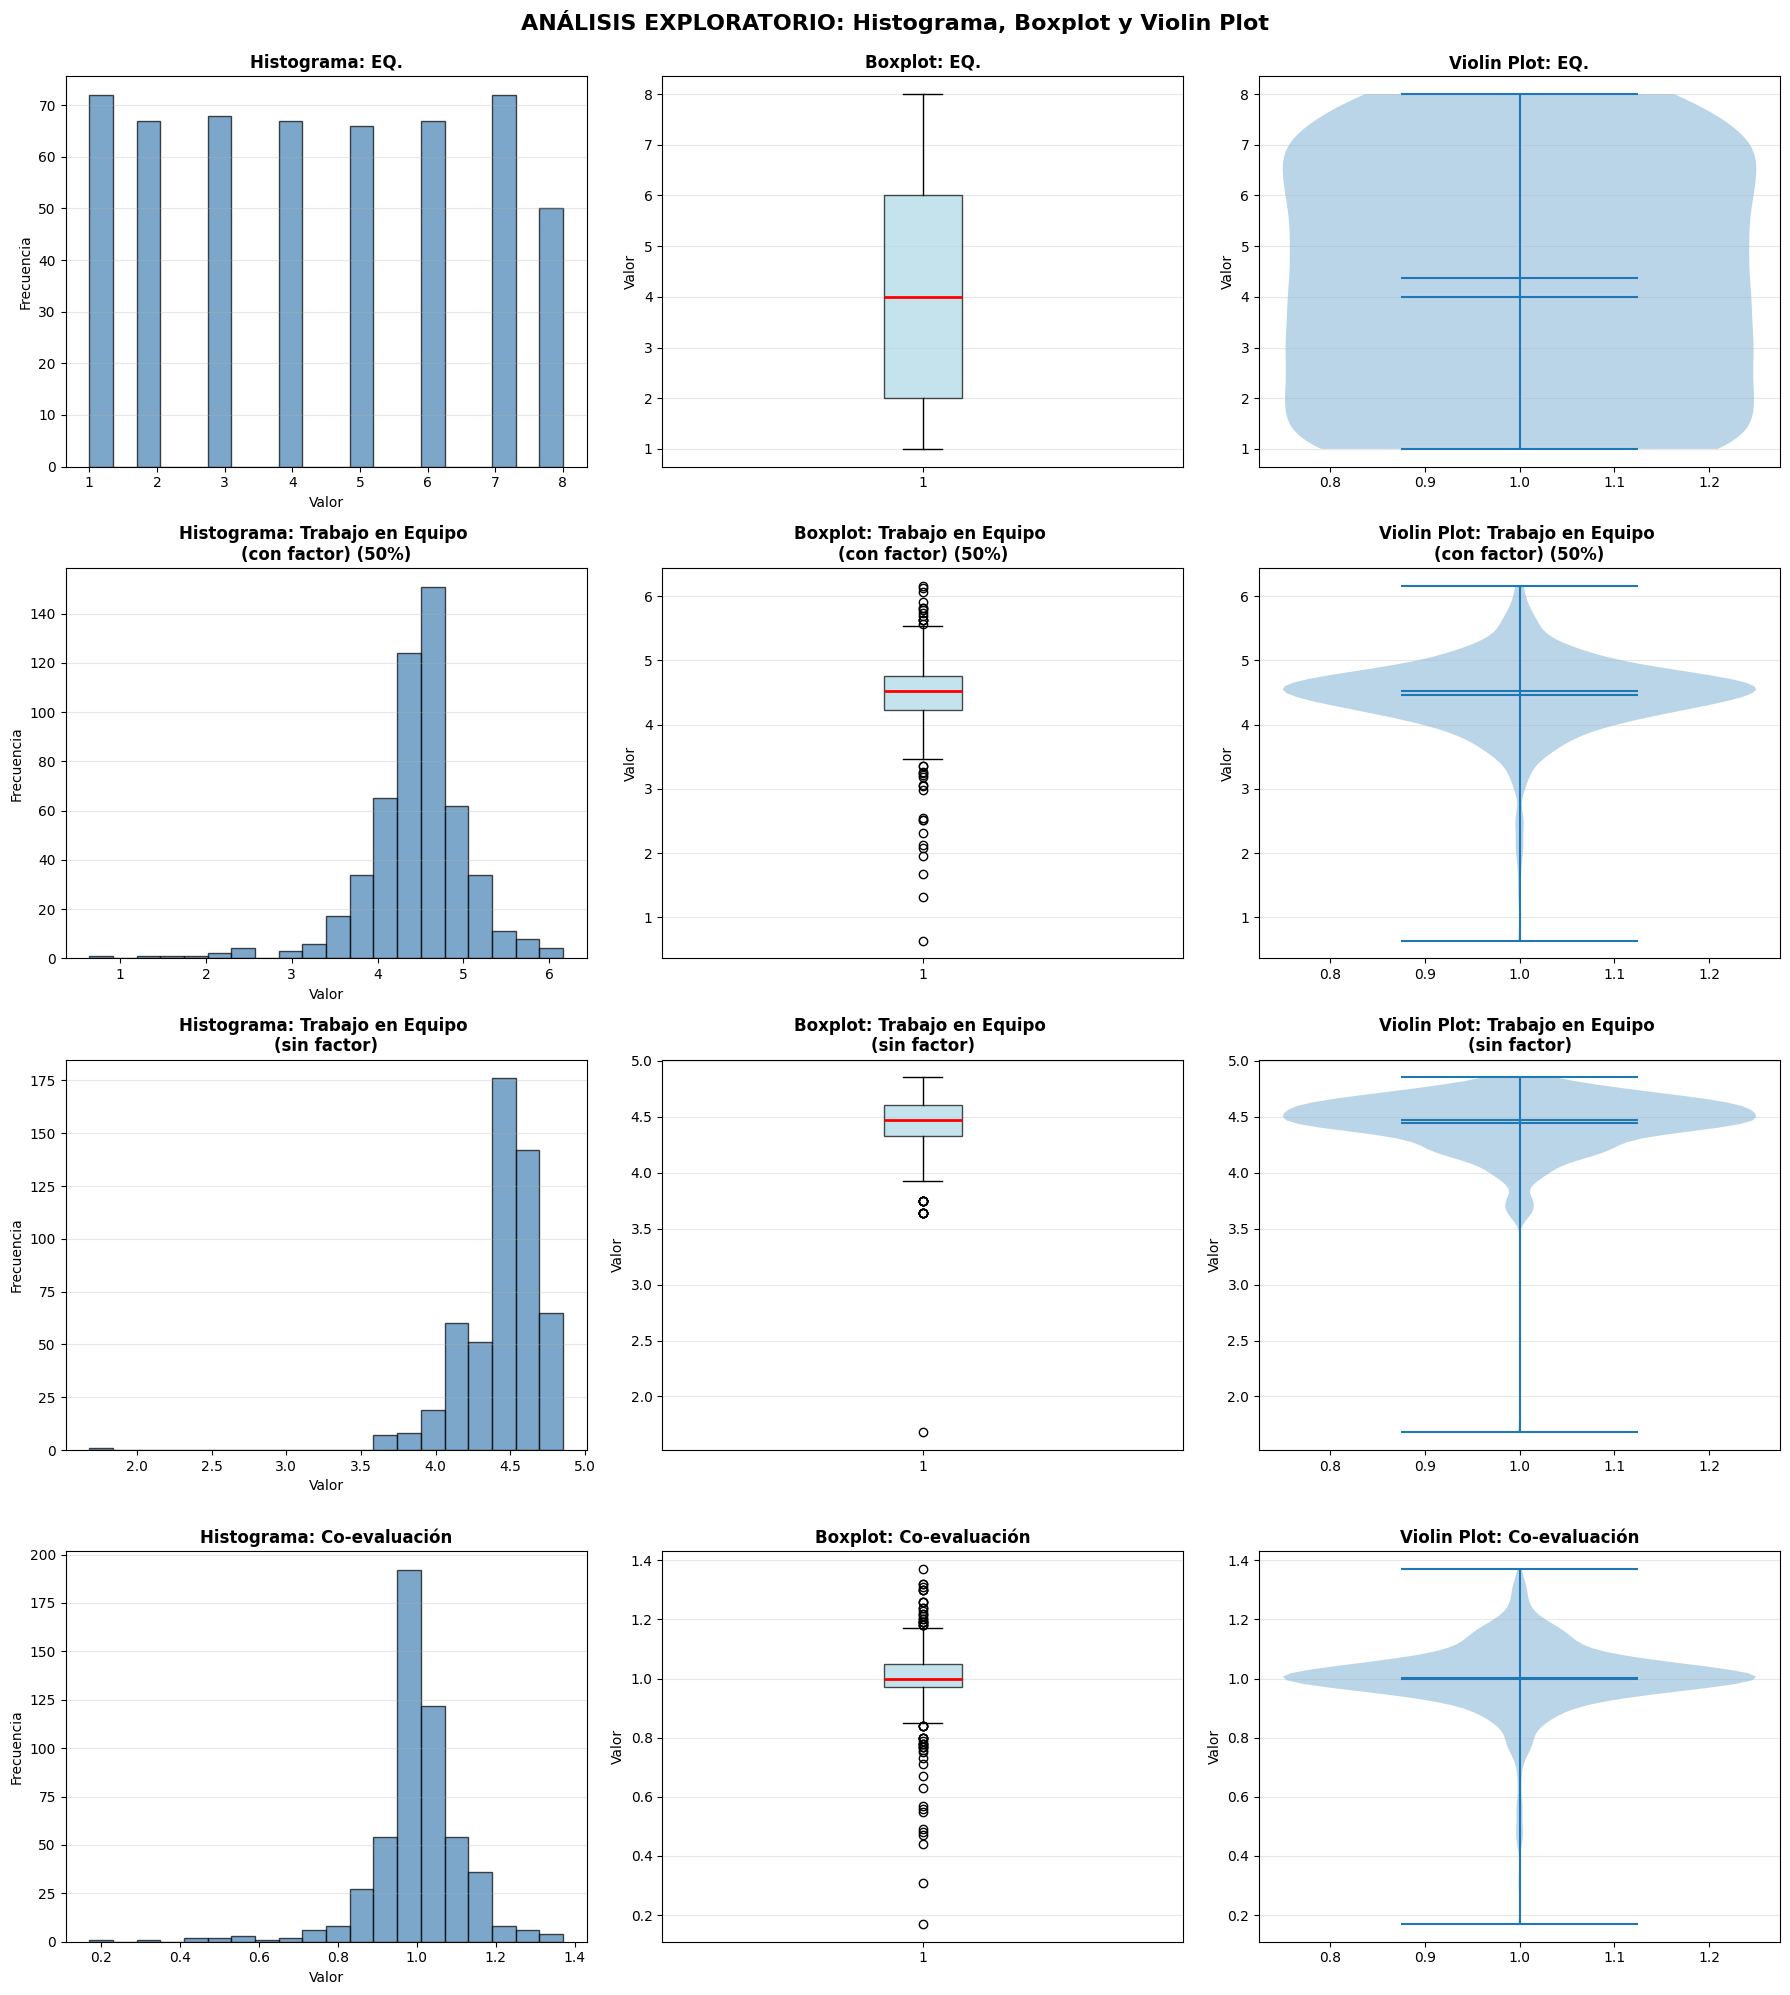

ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS

              EQ.  Trabajo en Equipo \n(con factor) (50%)  Trabajo en Equipo \n(sin factor)  Co-evaluación
count  529.000000                              529.000000                        529.000000     529.000000
mean     4.374291                                4.459395                          4.444063       1.003310
std      2.257936                                0.593460                          0.262422       0.120387
min      1.000000                                0.640000                          1.680000       0.170000
25%      2.000000                                4.220000                          4.327915       0.970000
50%      4.000000                                4.520000                          4.475767       1.000000
75%      6.000000                                4.750000                          4.609235       1.050000
max      8.000000                                6.160000                          4.852667   

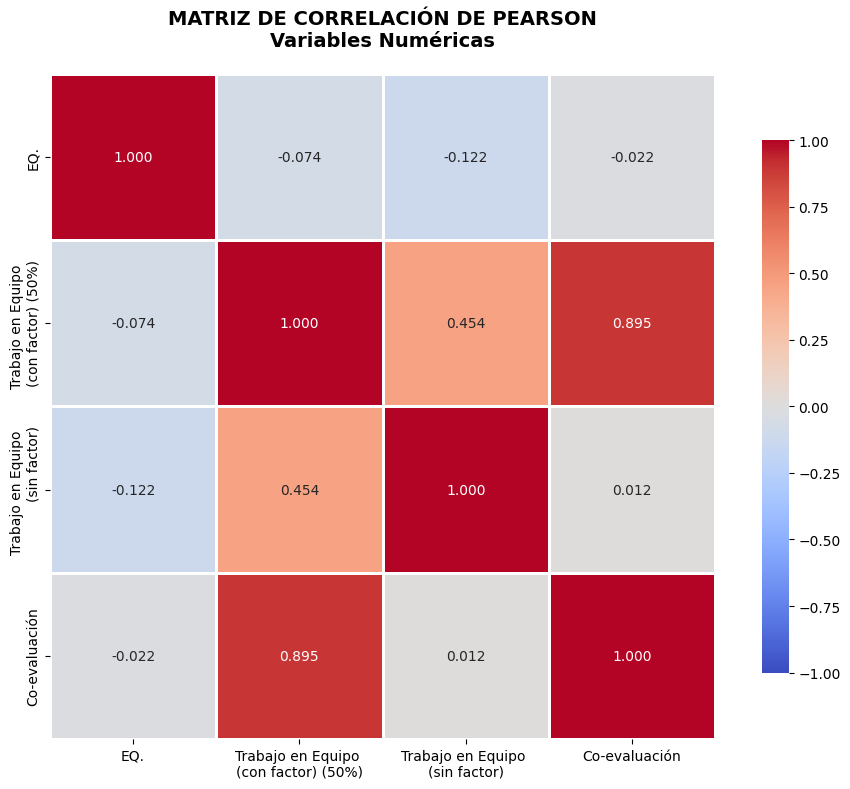

CORRELACIONES POR PARES - ANÁLISIS DETALLADO

                          Variable 1                           Variable 2  Pearson r  Pearson p-value  Spearman r  Spearman p-value
Trabajo en Equipo \n(con factor) (50     Trabajo en Equipo \n(sin factor)     0.4537         0.000000      0.4906          0.000000
Trabajo en Equipo \n(con factor) (50                        Co-evaluación     0.8949         0.000000      0.8068          0.000000
                                 EQ.     Trabajo en Equipo \n(sin factor)    -0.1223         0.004856     -0.1289          0.002969
                                 EQ. Trabajo en Equipo \n(con factor) (50    -0.0742         0.088074     -0.0744          0.087276
                                 EQ.                        Co-evaluación    -0.0217         0.618397     -0.0014          0.974040
    Trabajo en Equipo \n(sin factor)                        Co-evaluación     0.0123         0.777888     -0.0192          0.659975

CORRELACIONES SIGNIFICATIVAS 

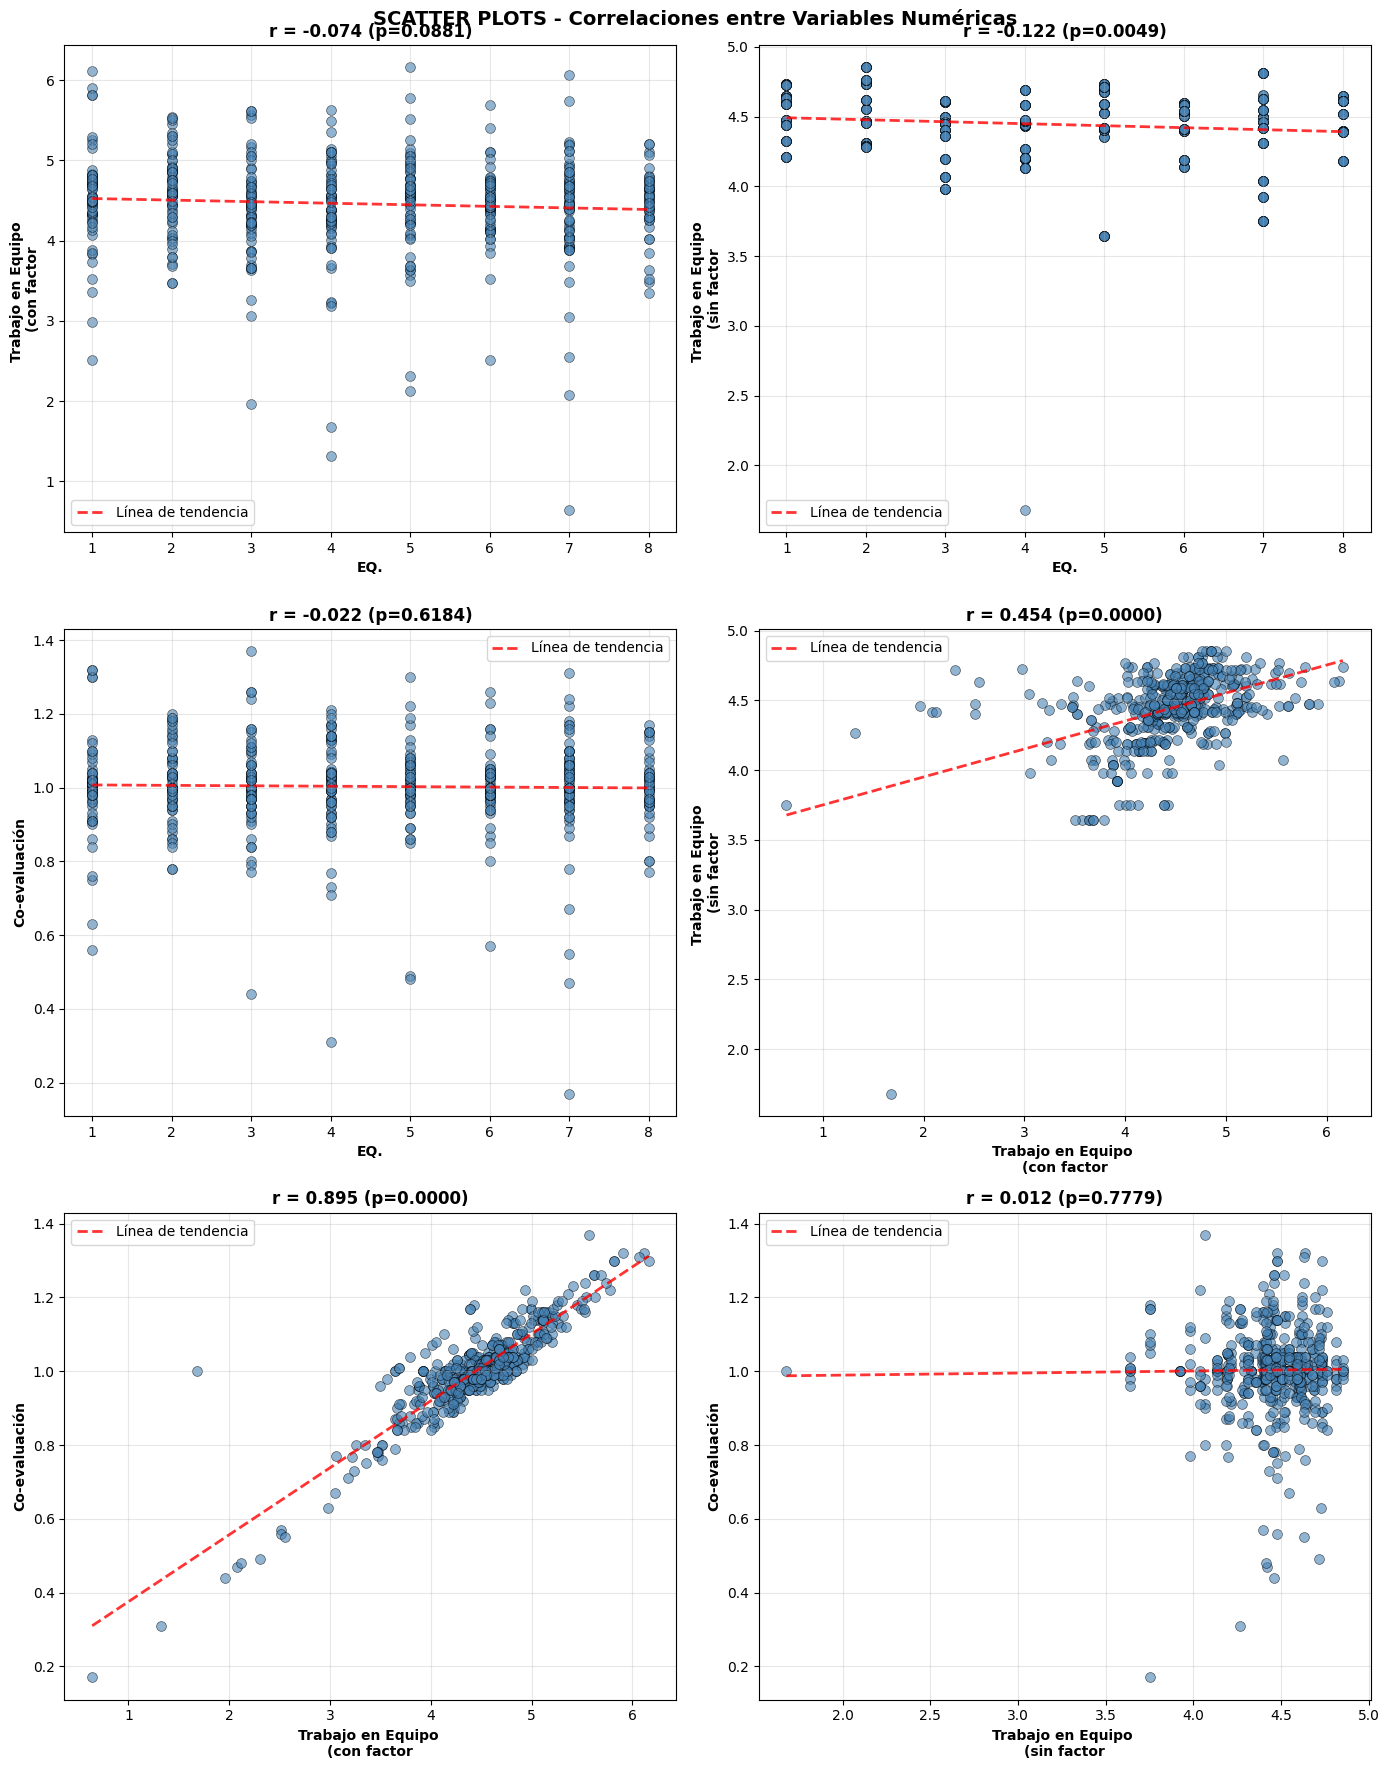


Color Test de predominancia:
Color Test de predominancia
Tipo A - Azul       251
Tipo B - Verde      143
Tipo C - Rojo        74
Tipo D - Naranja     61

Etiqueta Semestre-Grupo:
Etiqueta Semestre-Grupo
2023-02-G3       59
2023-01-G3       58
2024-02-G3       57
2024-01-G3       57
2022-02-G3       54
2021-01-G7       51
2021-02-G3-G7    49
2022-01-G3       49
2025-01-G3       49
2025-02-G3       46


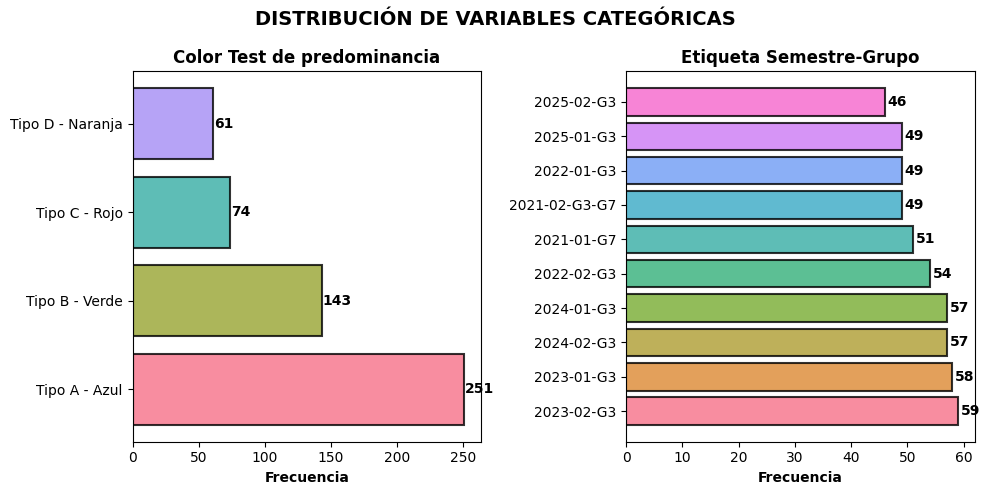

C:\Users\osqui\AppData\Local\Temp\ipykernel_30952\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_30952\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_30952\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local

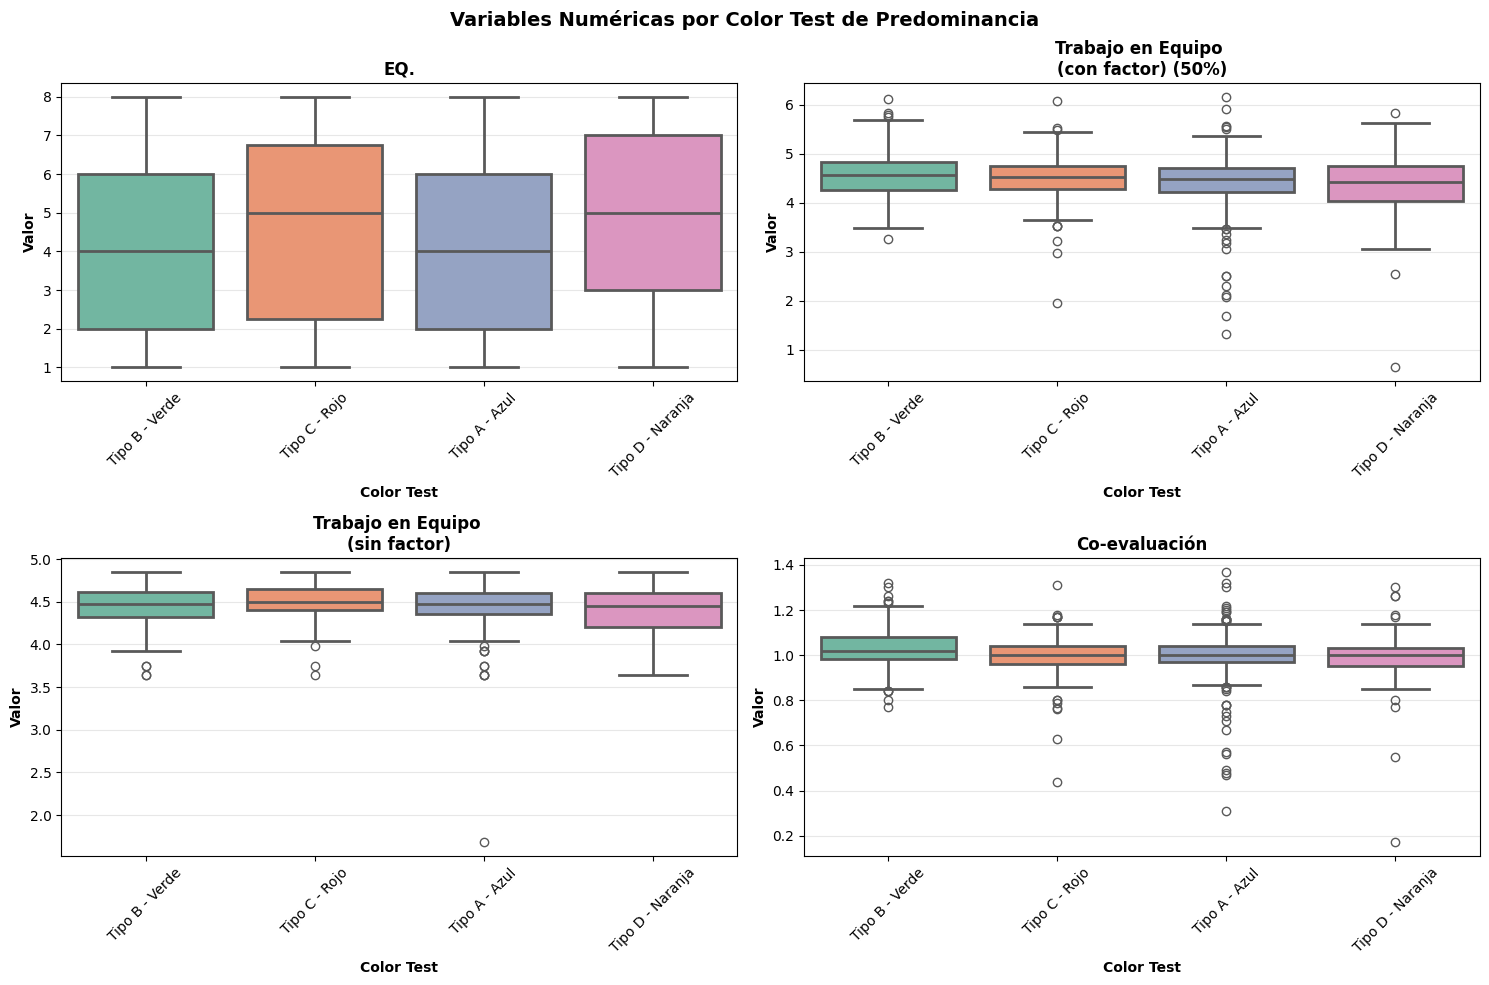

C:\Users\osqui\AppData\Local\Temp\ipykernel_30952\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_30952\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_30952\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Te

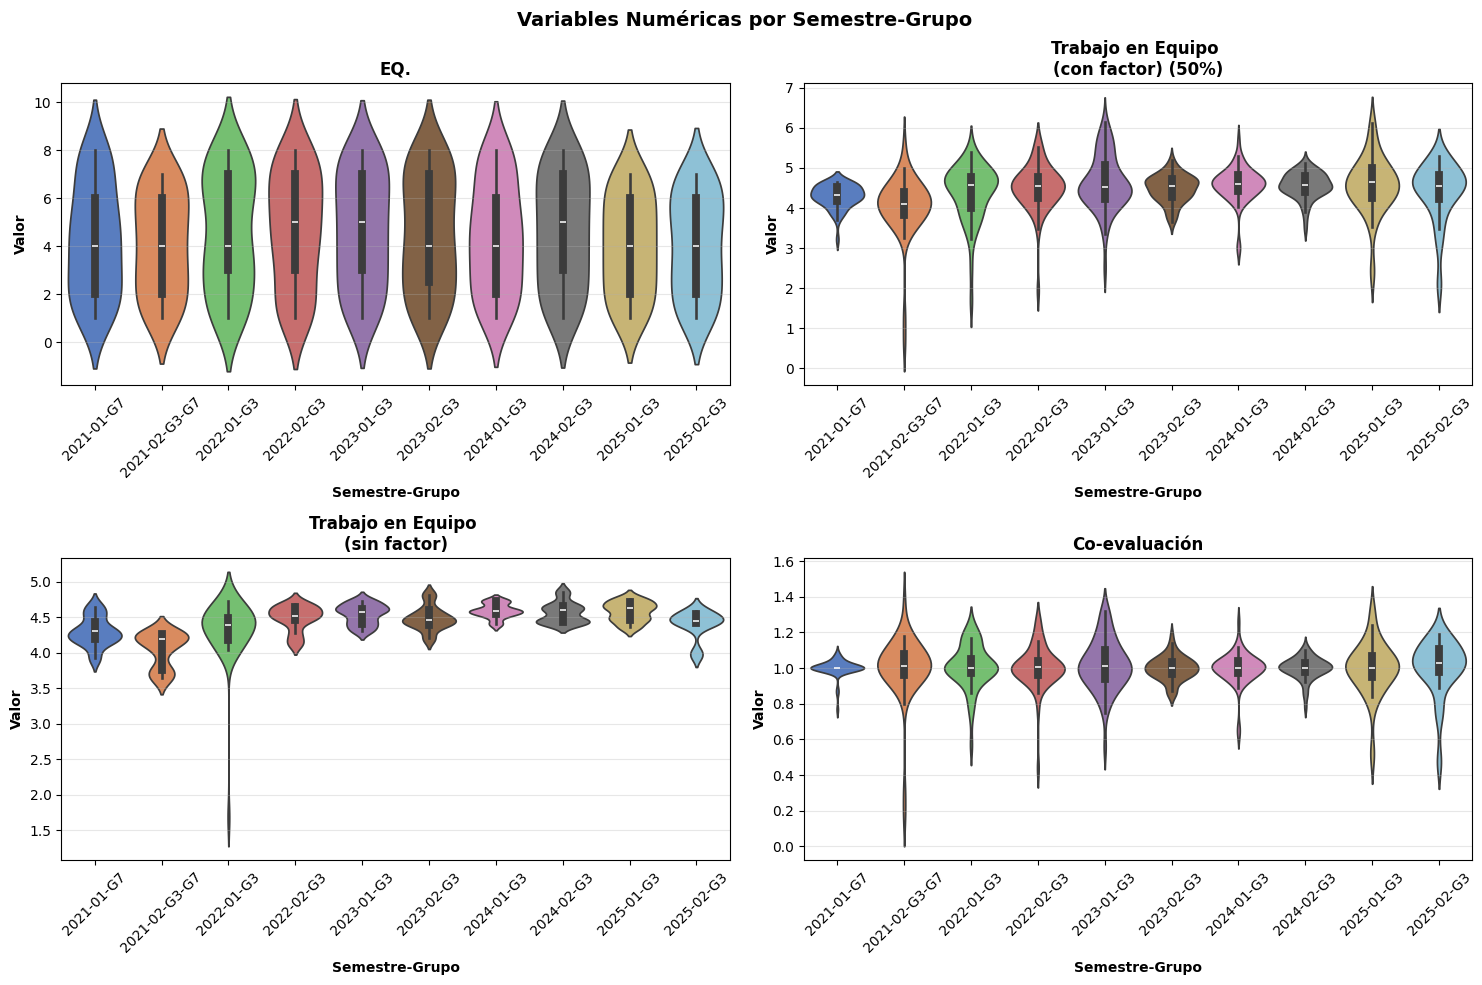

In [8]:
solo_data = dataset_raw.copy().drop(columns=['CARRERA']).set_index('ID')
EDA(solo_data)

# EDA (Grupal)

In [9]:
solo_data.columns.tolist()

['EQ.',
 'Trabajo en Equipo \n(con factor) (50%)',
 'Trabajo en Equipo \n(sin factor)',
 'Co-evaluación',
 'Color Test de predominancia',
 'Etiqueta Semestre-Grupo']

In [10]:
# Agrupación por equipo y etiqueta de semestre-grupo
# Esto calcula la cantidad de integrantes y suma el número de cada tipo de color,
# además del promedio de la nota de Trabajo en Equipo (sin factor).

grouped = solo_data.reset_index().groupby(['Etiqueta Semestre-Grupo', 'EQ.'])

integrantes = grouped.size().rename('Integrantes')
color_counts = grouped['Color Test de predominancia'].value_counts().unstack(fill_value=0)

coevaluation_mean = grouped['Co-evaluación'].mean().rename('Promedio Co-evaluacion')
coevaluation_std = grouped['Co-evaluación'].std().rename('Desv. Estándar Co-evaluacion')
cv_evaluation = (coevaluation_std / coevaluation_mean).rename('CV Co-evaluacion')

# Mínimo de coevaluación por equipo
coevaluation_min = grouped['Co-evaluación'].min().rename('Min Co-evaluacion')

# Normalización dinámica de la desviación estándar
std_min = coevaluation_std.min()
std_max = coevaluation_std.max()

std_normalized = (
    (coevaluation_std - std_min) / (std_max - std_min)
).rename('Std Normalized Co-evaluacion')

# Índice de cohesión grupal
cohesion_index = (
    coevaluation_mean * (1 - std_normalized)
).rename('Indice Cohesion Grupal')


group_data = (
    integrantes.to_frame()
    .join(color_counts)
    .join(cv_evaluation)
    .join(coevaluation_mean)
    .join(coevaluation_std)
    .join(coevaluation_min)
    .join(cohesion_index)
)

group_data = pd.DataFrame(group_data[
    [
        'Integrantes',
        'Tipo A - Azul',
        'Tipo B - Verde',
        'Tipo C - Rojo',
        'Tipo D - Naranja',
        'CV Co-evaluacion',
        'Promedio Co-evaluacion',
        'Desv. Estándar Co-evaluacion',
        'Min Co-evaluacion',
        'Indice Cohesion Grupal'
    ]
])                                      
group_data.reset_index(inplace=True)
group_data.drop(columns=['Etiqueta Semestre-Grupo', 'EQ.', 'Integrantes'], inplace=True)
for col in group_data.columns: group_data[col] = group_data[col].astype(float)
group_data

,Tipo A - Azul,Tipo B - Verde,Tipo C - Rojo,Tipo D - Naranja,CV Co-evaluacion,Promedio Co-evaluacion,Desv. Estándar Co-evaluacion,Min Co-evaluacion,Indice Cohesion Grupal
0,4.0,1.0,1.0,1.0,0.000000,1.000000,0.000000,1.000,1.000000
1,2.0,3.0,1.0,2.0,0.086520,1.000000,0.086520,0.860,0.756759
2,2.0,3.0,0.0,1.0,0.000000,1.000000,0.000000,1.000,1.000000
3,3.0,1.0,2.0,1.0,0.102774,1.000143,0.102789,0.768,0.711123
4,4.0,2.0,0.0,1.0,0.000000,1.000000,0.000000,1.000,1.000000
...,...,...,...,...,...,...,...,...,...
72,1.0,4.0,1.0,1.0,0.120277,1.000000,0.120277,0.770,0.661854
73,2.0,1.0,1.0,1.0,0.182029,1.026000,0.186762,0.710,0.487289
74,2.0,2.0,1.0,2.0,0.240832,1.000000,0.240832,0.480,0.322929
75,4.0,2.0,1.0,0.0,0.035271,1.001429,0.035322,0.940,0.901984


In [11]:
# CREACIÓN DE VARIABLES DERIVADAS: ANALÍTICA DE EQUIPOS Y DIVERSIDAD GRUPAL

# Nombres de columnas de tipos conductuales
TIPOS = ['Tipo A - Azul', 'Tipo B - Verde', 'Tipo C - Rojo', 'Tipo D - Naranja']

# 1. TOTAL DE INTEGRANTES
# Métrica: Suma total de integrantes del equipo
# Interpretación: Tamaño del equipo

group_data['total_integrantes'] = group_data[TIPOS].sum(axis=1)

# 2. PROPORCIONES POR TIPO
# Métrica: Proporción de cada perfil dentro del equipo
# Fórmula: cantidad_tipo / total_integrantes
# Interpretación: Peso relativo de cada perfil conductual

for tipo in TIPOS:
    nombre_columna = f'prop_{tipo.split(" - ")[1].lower()}'
    group_data[nombre_columna] = group_data[tipo] / group_data['total_integrantes']

# 3. ÍNDICE DE DIVERSIDAD DE SHANNON
# Métrica: Índice de Shannon (entropía)
# Fórmula: H = -sum(p_i * ln(p_i))
# Rango: [0, ln(k)] donde k es el número de tipos
# Interpretación:
#   - Valores altos: Mayor diversidad de perfiles
#   - Valores bajos: Menor diversidad (dominancia de pocos perfiles)

def calcular_shannon(row):
    """
    Calcula el índice de diversidad de Shannon para una fila.
    Ignora proporciones de 0 para evitar ln(0) indefinido.
    """
    proporciones = [row[f'prop_{tipo.split(" - ")[1].lower()}'] 
                    for tipo in TIPOS]
    # Filtrar valores mayores a 0 (evita ln(0) = indefinido)
    proporciones_validas = [p for p in proporciones if p > 0]
    
    if len(proporciones_validas) == 0:
        return 0
    
    shannon = -sum([p * np.log(p) for p in proporciones_validas])
    return shannon

group_data['diversidad_shannon'] = group_data.apply(calcular_shannon, axis=1)

# 4. ÍNDICE DE DOMINANCIA DEL EQUIPO
# Métrica: Proporción del perfil predominante
# Fórmula: max(cantidad_tipo) / total_integrantes
# Rango: [0, 1]
# Interpretación:
#   - Cercano a 1: Un perfil domina fuertemente el equipo (bajo balance)
#   - Cercano a 1/k (k=4): Distribución equilibrada

group_data['dominancia_equipo'] = group_data[TIPOS].max(axis=1) / group_data['total_integrantes']

# 5. CANTIDAD DE PERFILES ÚNICOS
# Métrica: Número de perfiles conductuales presentes en el equipo
# Rango: [1, 4]
# Interpretación:
#   - Valor alto: Mayor diversidad de tipos
#   - Valor bajo: Equipo con pocos tipos de perfiles

def contar_perfiles_unicos(row):
    """
    Cuenta cuántos tipos conductuales están presentes (cantidad > 0)
    en el equipo.
    """
    cantidades = [row[tipo] for tipo in TIPOS]
    return sum([1 for cant in cantidades if cant > 0])

group_data['cantidad_perfiles_unicos'] = group_data.apply(contar_perfiles_unicos, axis=1)

# 6. ÍNDICE DE BALANCE DEL EQUIPO
# Métrica: Medida de equilibrio en la distribución de perfiles
# Fórmula: 1 - std(proporciones)
# Rango: [0, 1]
# Interpretación:
#   - Cercano a 1: Distribución equilibrada (todos los perfiles representados)
#   - Cercano a 0: Distribución desbalanceada (dominancia de pocos perfiles)
# Nota: Se calcula solo con proporciones de perfiles presentes (> 0)

def calcular_balance(row):
    """
    Calcula el índice de balance como 1 - desviación estándar
    de las proporciones de perfiles presentes.
    """
    proporciones = [row[f'prop_{tipo.split(" - ")[1].lower()}'] 
                    for tipo in TIPOS]
    proporciones_validas = [p for p in proporciones if p > 0]
    
    if len(proporciones_validas) <= 1:
        # Si hay solo un perfil o ninguno, balance es 0
        return 0
    
    desv_est = np.std(proporciones_validas)
    balance = 1 - desv_est
    
    return balance

group_data['balance_equipo'] = group_data.apply(calcular_balance, axis=1)

In [12]:
group_data.head()

,Tipo A - Azul,Tipo B - Verde,Tipo C - Rojo,Tipo D - Naranja,CV Co-evaluacion,Promedio Co-evaluacion,Desv. Estándar Co-evaluacion,Min Co-evaluacion,Indice Cohesion Grupal,total_integrantes,prop_azul,prop_verde,prop_rojo,prop_naranja,diversidad_shannon,dominancia_equipo,cantidad_perfiles_unicos,balance_equipo
0,4.0,1.0,1.0,1.0,0.000000,1.000000,0.000000,1.000,1.000000,7.0,0.571429,0.142857,0.142857,0.142857,1.153742,0.571429,4,0.814423
1,2.0,3.0,1.0,2.0,0.086520,1.000000,0.086520,0.860,0.756759,8.0,0.250000,0.375000,0.125000,0.250000,1.320888,0.375000,4,0.911612
2,2.0,3.0,0.0,1.0,0.000000,1.000000,0.000000,1.000,1.000000,6.0,0.333333,0.500000,0.000000,0.166667,1.011404,0.500000,3,0.863917
3,3.0,1.0,2.0,1.0,0.102774,1.000143,0.102789,0.768,0.711123,7.0,0.428571,0.142857,0.285714,0.142857,1.277034,0.428571,4,0.881549
4,4.0,2.0,0.0,1.0,0.000000,1.000000,0.000000,1.000,1.000000,7.0,0.571429,0.285714,0.000000,0.142857,0.955700,0.571429,3,0.821826


In [13]:
group_data.columns.tolist()

['Tipo A - Azul',
 'Tipo B - Verde',
 'Tipo C - Rojo',
 'Tipo D - Naranja',
 'CV Co-evaluacion',
 'Promedio Co-evaluacion',
 'Desv. Estándar Co-evaluacion',
 'Min Co-evaluacion',
 'Indice Cohesion Grupal',
 'total_integrantes',
 'prop_azul',
 'prop_verde',
 'prop_rojo',
 'prop_naranja',
 'diversidad_shannon',
 'dominancia_equipo',
 'cantidad_perfiles_unicos',
 'balance_equipo']


ANÁLISIS DE CORRELACIÓN: CV Co-evaluacion



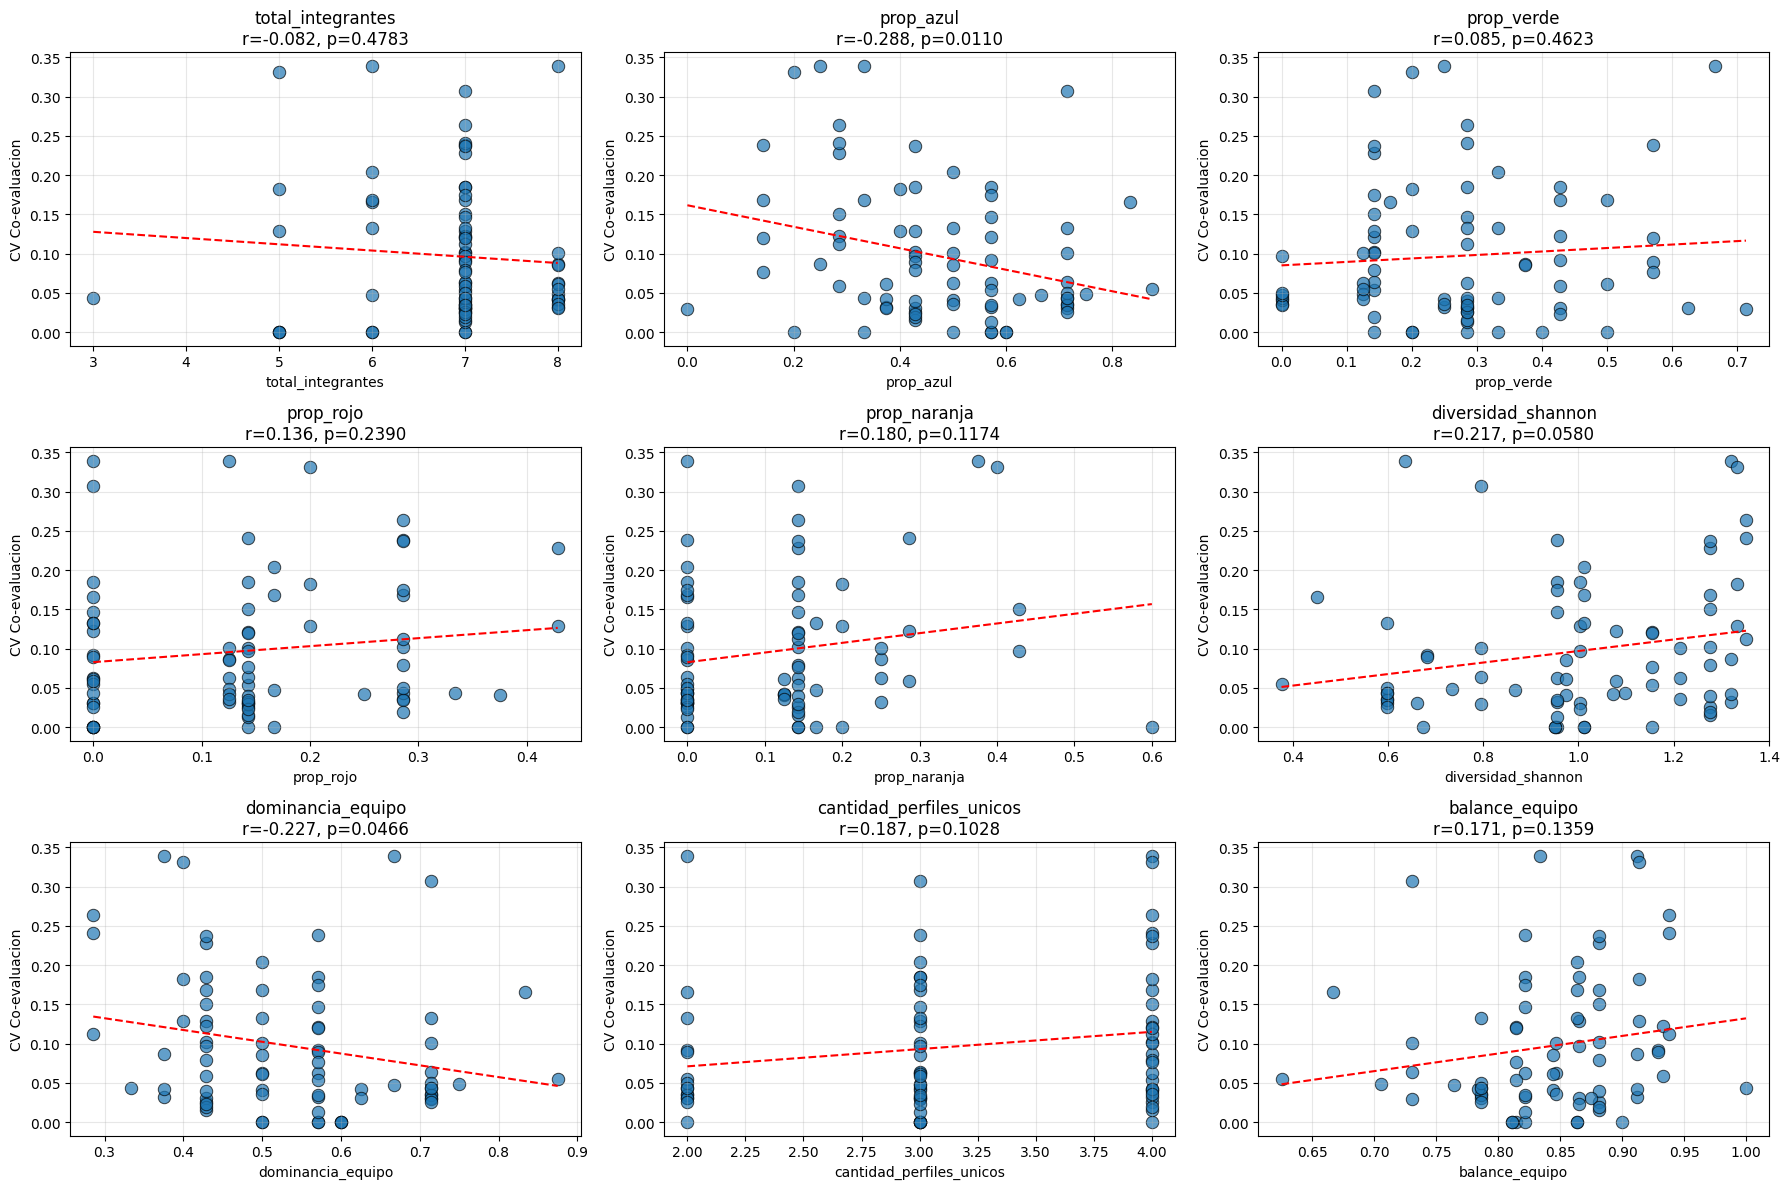

Correlaciones (Pearson r) y p-values:

                variable  pearson_r  pearson_p
               prop_azul  -0.288202   0.011029
       dominancia_equipo  -0.227465   0.046645
      diversidad_shannon   0.216988   0.058017
cantidad_perfiles_unicos   0.187359   0.102751
            prop_naranja   0.179900   0.117442
          balance_equipo   0.171494   0.135880
               prop_rojo   0.135795   0.238966
              prop_verde   0.085011   0.462279
       total_integrantes  -0.081999   0.478347

ANÁLISIS DE CORRELACIÓN: Promedio Co-evaluacion



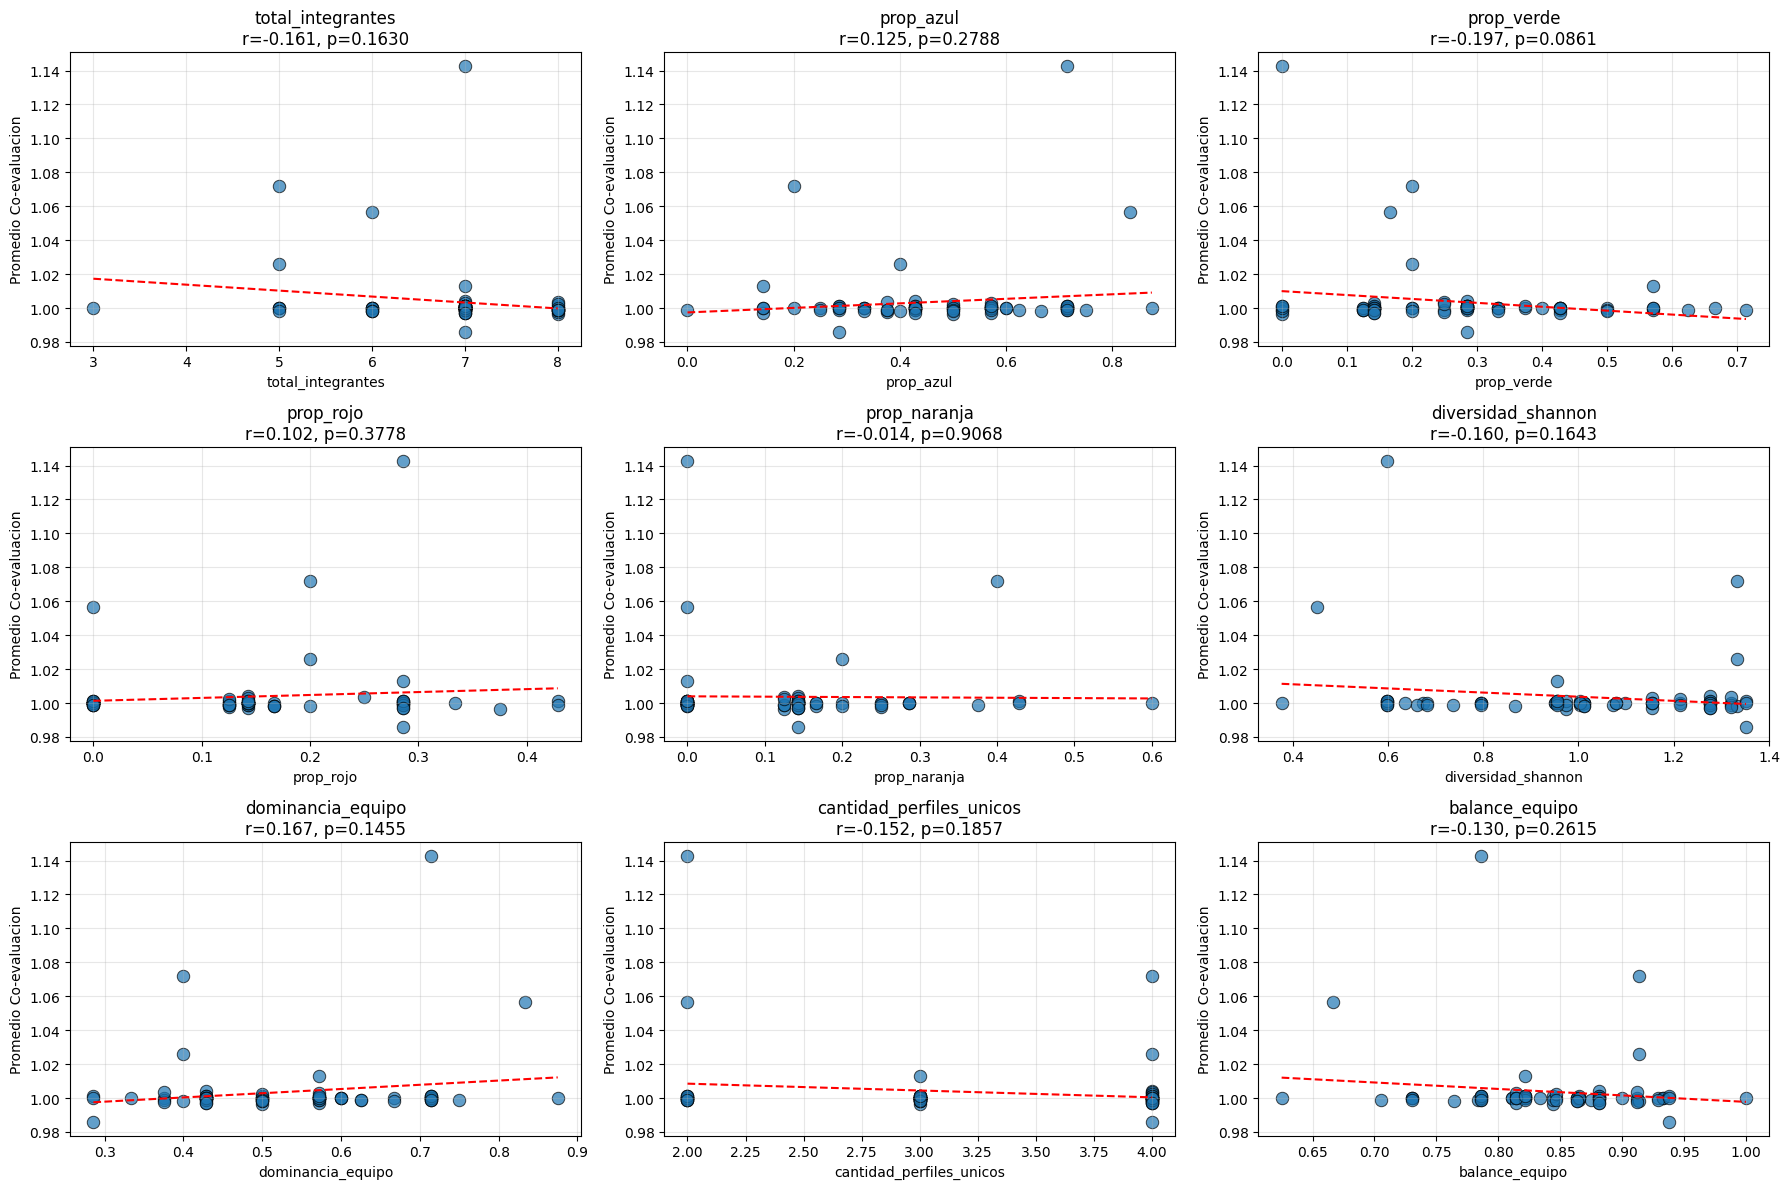

Correlaciones (Pearson r) y p-values:

                variable  pearson_r  pearson_p
              prop_verde  -0.196917   0.086066
       dominancia_equipo   0.167450   0.145494
       total_integrantes  -0.160558   0.163041
      diversidad_shannon  -0.160074   0.164330
cantidad_perfiles_unicos  -0.152440   0.185661
          balance_equipo  -0.129553   0.261451
               prop_azul   0.124971   0.278840
               prop_rojo   0.101916   0.377788
            prop_naranja  -0.013564   0.906796

ANÁLISIS DE CORRELACIÓN: Desv. Estándar Co-evaluacion



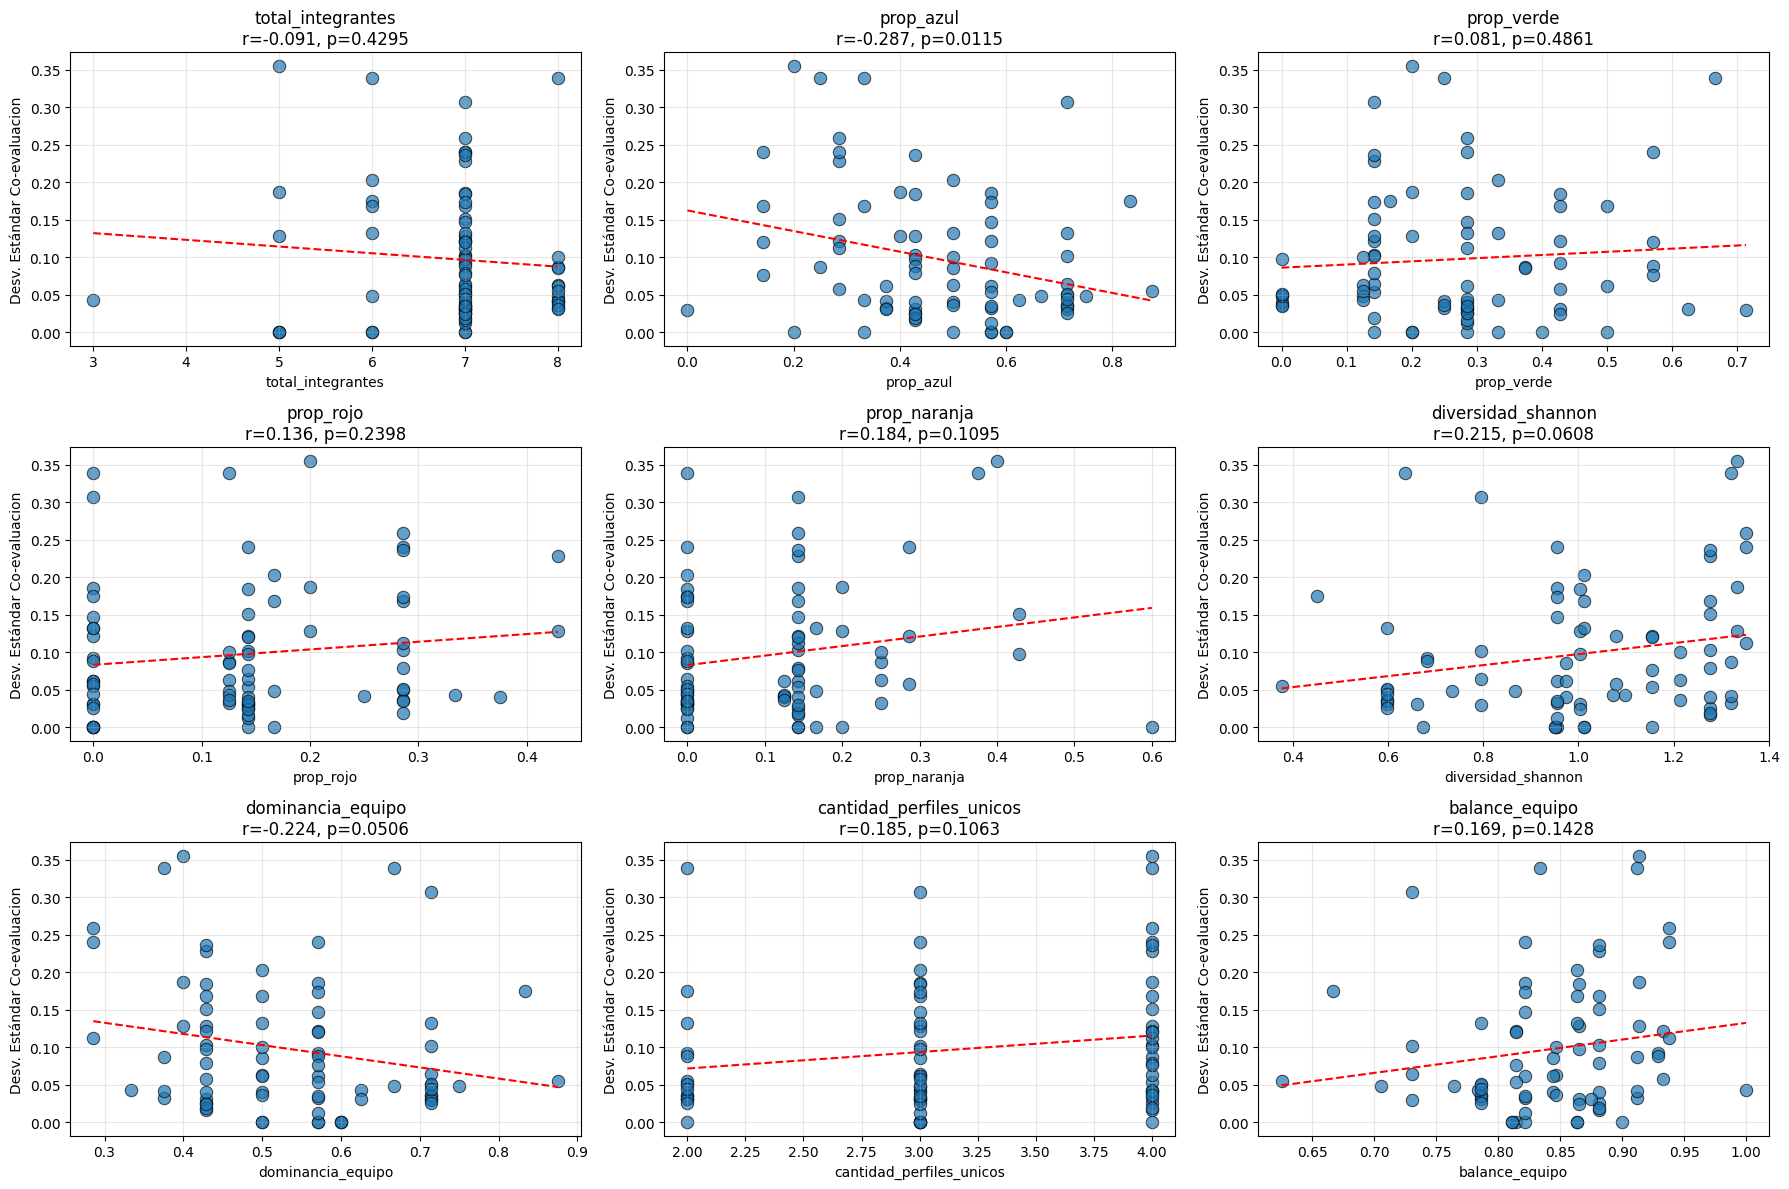

Correlaciones (Pearson r) y p-values:

                variable  pearson_r  pearson_p
               prop_azul  -0.286717   0.011468
       dominancia_equipo  -0.223622   0.050581
      diversidad_shannon   0.214688   0.060794
cantidad_perfiles_unicos   0.185479   0.106310
            prop_naranja   0.183832   0.109508
          balance_equipo   0.168542   0.142848
               prop_rojo   0.135570   0.239753
       total_integrantes  -0.091345   0.429472
              prop_verde   0.080569   0.486077

ANÁLISIS DE CORRELACIÓN: Min Co-evaluacion



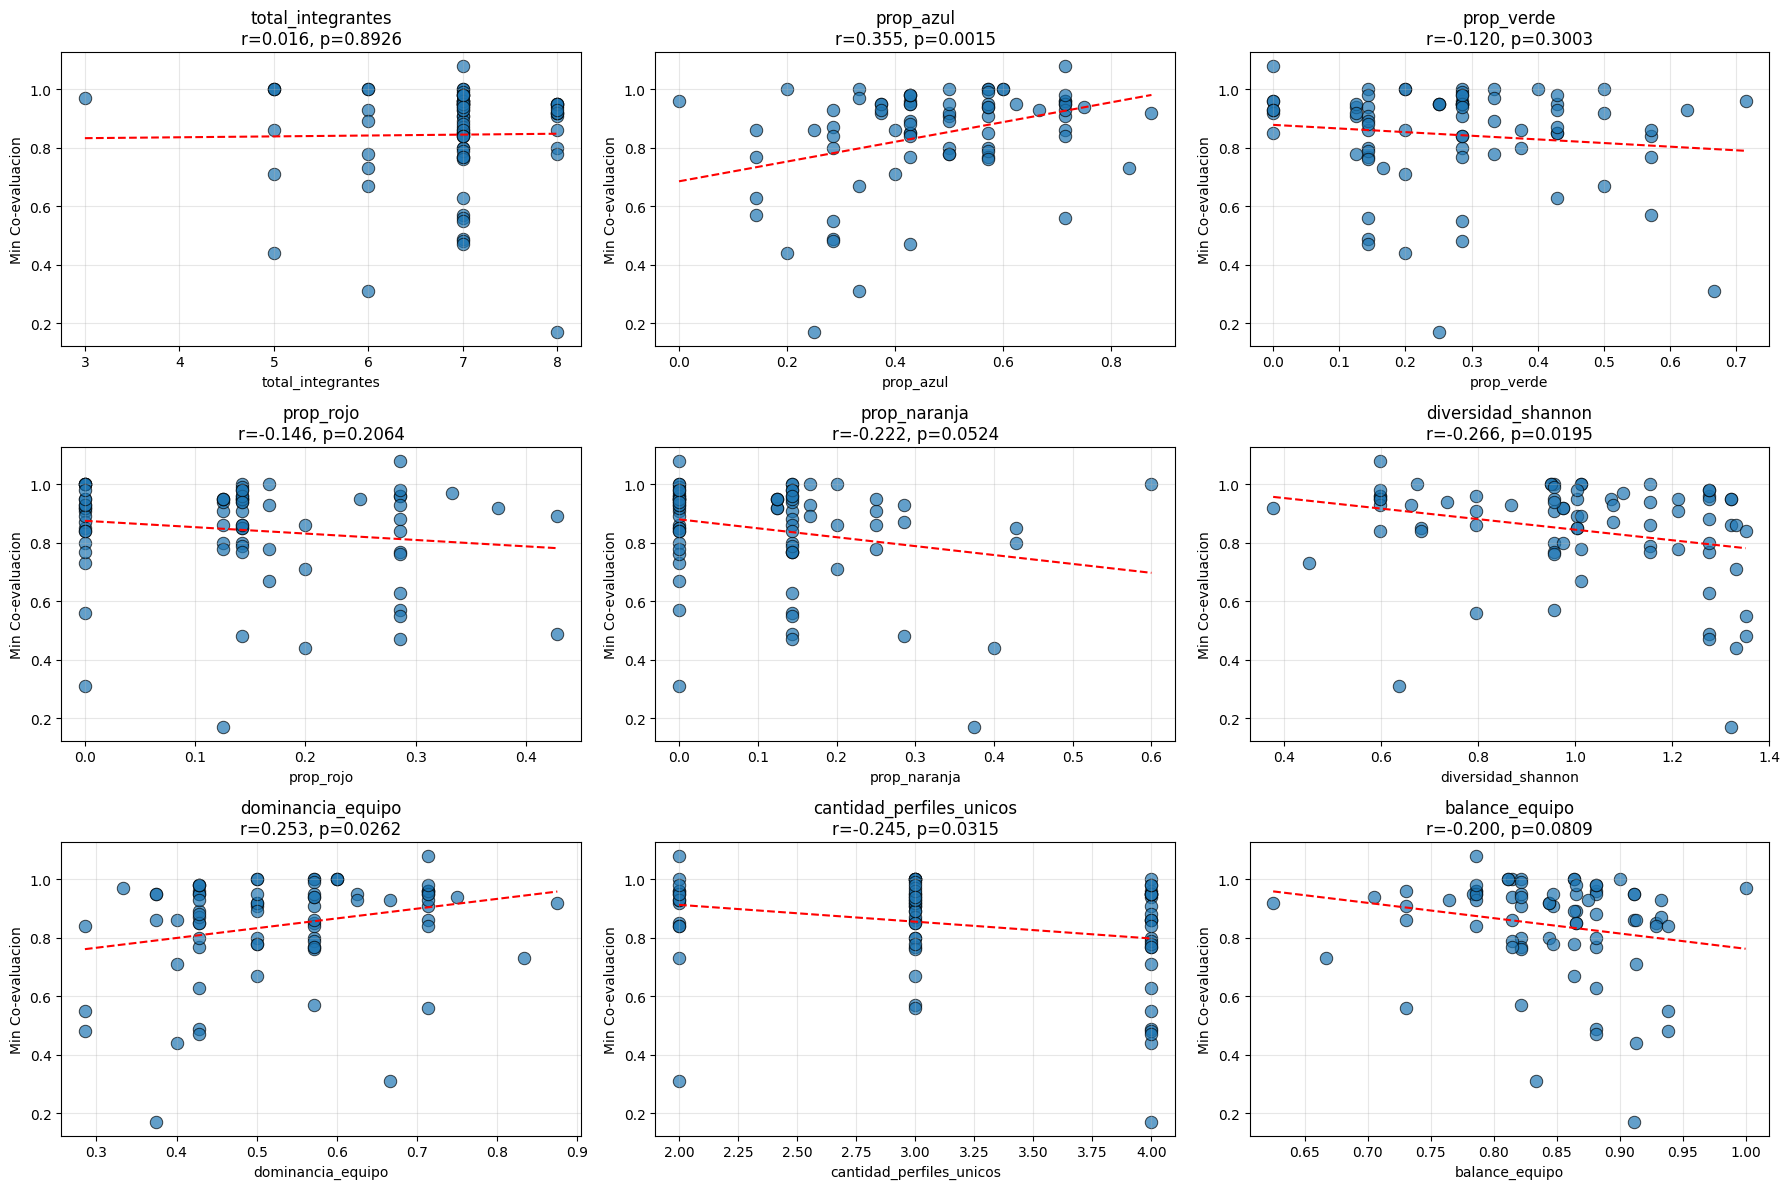

Correlaciones (Pearson r) y p-values:

                variable  pearson_r  pearson_p
               prop_azul   0.355096   0.001530
      diversidad_shannon  -0.265631   0.019549
       dominancia_equipo   0.253322   0.026221
cantidad_perfiles_unicos  -0.245302   0.031533
            prop_naranja  -0.221924   0.052405
          balance_equipo  -0.200166   0.080910
               prop_rojo  -0.145604   0.206404
              prop_verde  -0.119568   0.300311
       total_integrantes   0.015641   0.892605

ANÁLISIS DE CORRELACIÓN: Indice Cohesion Grupal



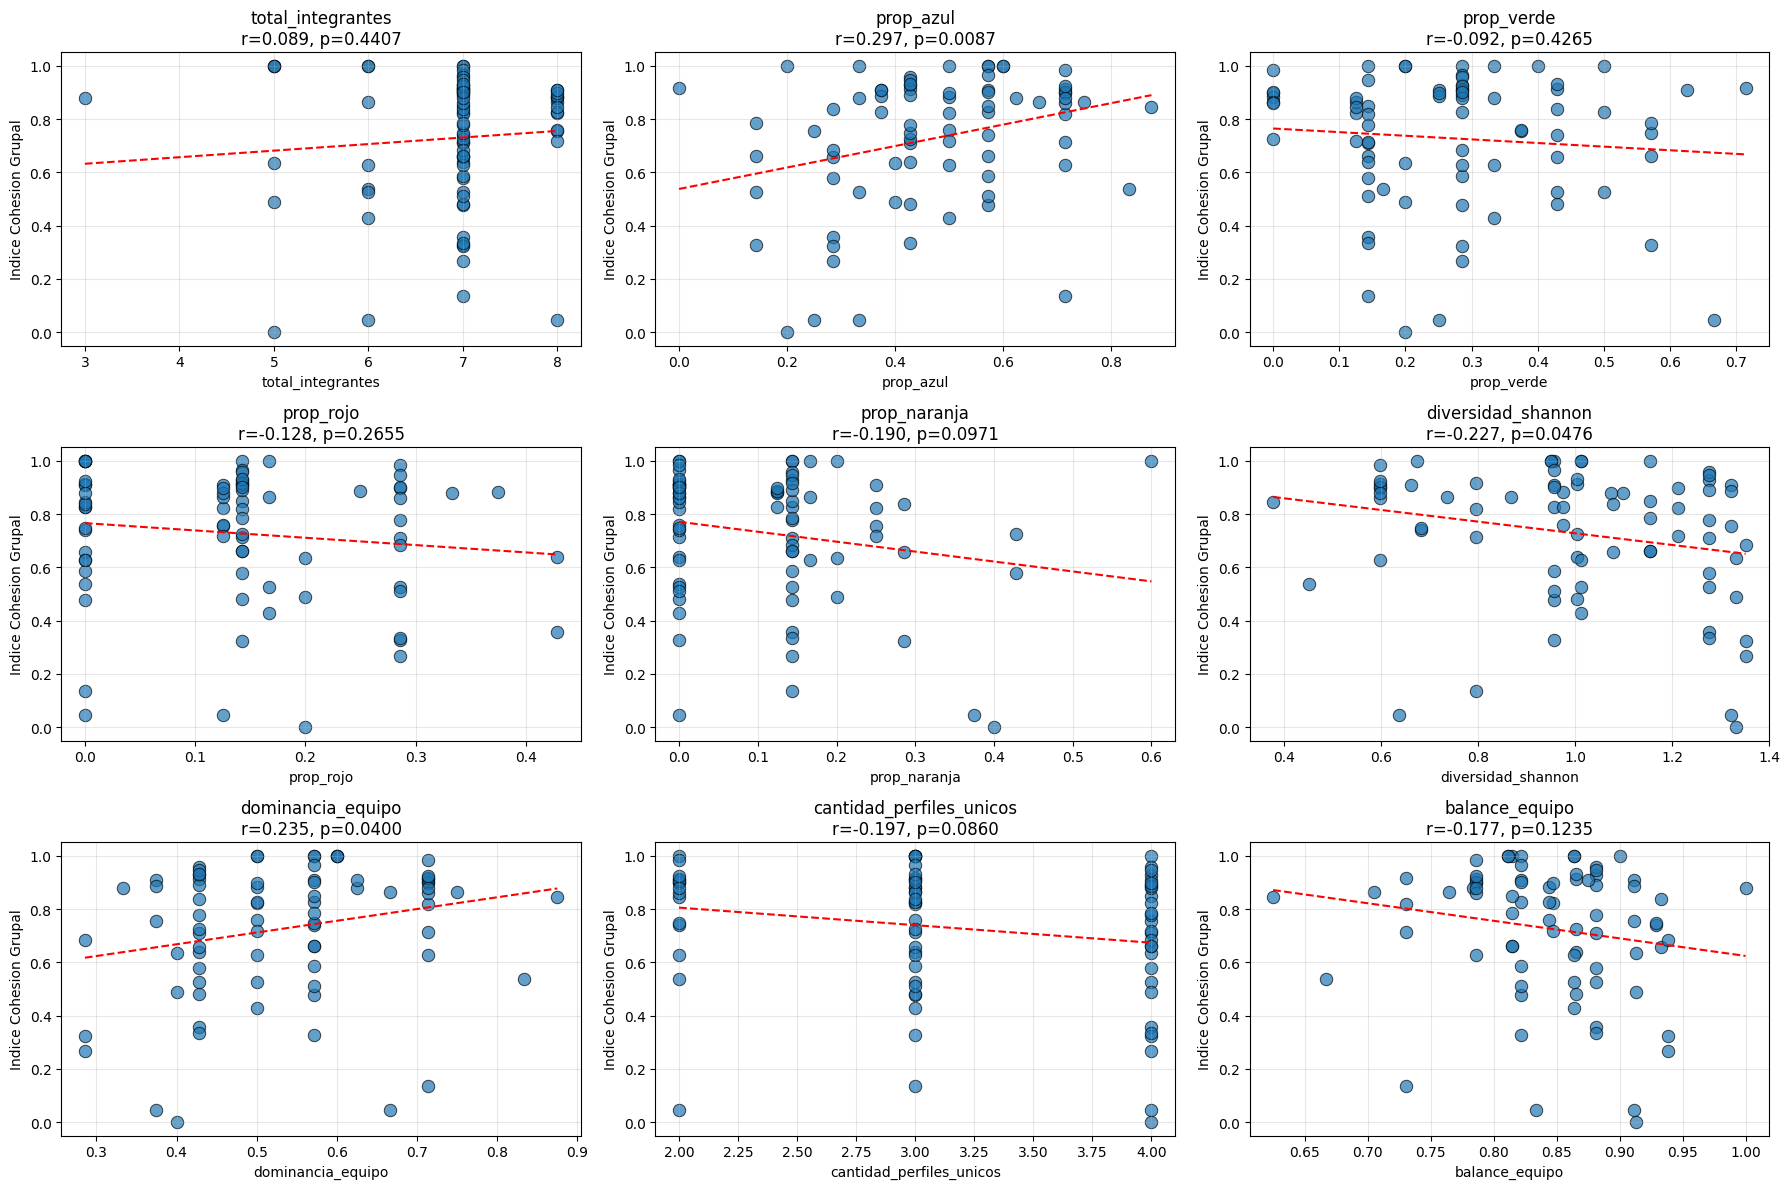

Correlaciones (Pearson r) y p-values:

                variable  pearson_r  pearson_p
               prop_azul   0.297206   0.008667
       dominancia_equipo   0.234564   0.040037
      diversidad_shannon  -0.226556   0.047552
cantidad_perfiles_unicos  -0.196942   0.086025
            prop_naranja  -0.190455   0.097091
          balance_equipo  -0.177023   0.123522
               prop_rojo  -0.128473   0.265483
              prop_verde  -0.091940   0.426463
       total_integrantes   0.089143   0.440724


In [14]:
# Análisis: scatterplots de variables de entrada vs variable objetivo
input_vars = ['total_integrantes', 'prop_azul', 'prop_verde', 'prop_rojo', 'prop_naranja',
              'diversidad_shannon', 'dominancia_equipo', 'cantidad_perfiles_unicos', 'balance_equipo']
target = ['CV Co-evaluacion', 'Promedio Co-evaluacion', 'Desv. Estándar Co-evaluacion', 
          'Min Co-evaluacion', 'Indice Cohesion Grupal']



n = len(input_vars)
cols = 3
rows = (n + cols - 1) // cols


for target in target:
    print(f'\n{"="*80}\nANÁLISIS DE CORRELACIÓN: {target}\n{"="*80}\n')
    results = []
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = axes.flatten()
    
    for i, var in enumerate(input_vars):
        ax = axes[i]
        sns.scatterplot(data=group_data, x=var, y=target, ax=ax, s=80, edgecolor='k', alpha=0.7)

        # Ajuste de línea de tendencia si hay al menos 2 puntos
        mask = group_data[[var, target]].dropna()
        if len(mask) > 1:
            z = np.polyfit(mask[var], mask[target], 1)
            p = np.poly1d(z)
            x_line = np.linspace(mask[var].min(), mask[var].max(), 100)
            ax.plot(x_line, p(x_line), color='red', linestyle='--')

            pearson_r, pearson_p = stats.pearsonr(mask[var], mask[target])
        else:
            pearson_r, pearson_p = np.nan, np.nan

        ax.set_title(f"{var}\nr={pearson_r:.3f}, p={pearson_p:.4f}")
        ax.set_xlabel(var)
        ax.set_ylabel(target)
        ax.grid(alpha=0.3)

        results.append({'variable': var, 'pearson_r': pearson_r, 'pearson_p': pearson_p})
    
    # Ocultar ejes sobrantes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    plt.close()
    # Mostrar tabla de correlaciones ordenada por p-value
    res_df = pd.DataFrame(results)
    res_df = res_df.sort_values('pearson_p')
    print('Correlaciones (Pearson r) y p-values:\n')
    print(res_df.to_string(index=False))
